In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/wildlife_dataset.zip" -d "/content/dataset"

replace /content/dataset/wildlife_dataset/amur_leopard/0053_al_n_crop00_detections.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import wandb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

!rm -f /root/.netrc
!rm -rf /root/.config/wandb
!rm -rf wandb

In [ ]:
import torch
import numpy as np
import random

SEED = 2023471

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED) 

np.random.seed(SEED)

random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✅ All random seeds successfully set to {SEED} for reproducibility!")

✅ All random seeds successfully set to 2023471 for reproducibility!


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: saksham2684 (saksham2684-indraprastha-institute-of-information-techno) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Total Training Images: 9334
Total Validation Images: 2334


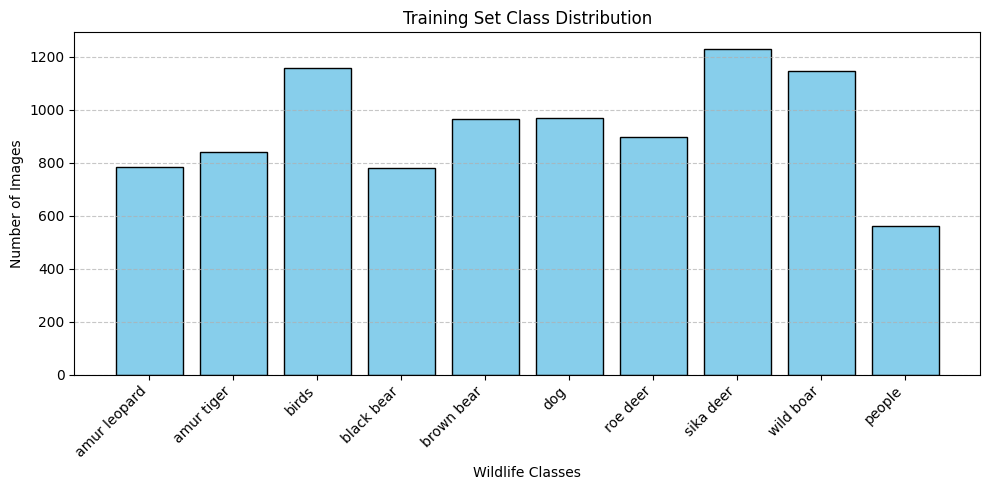

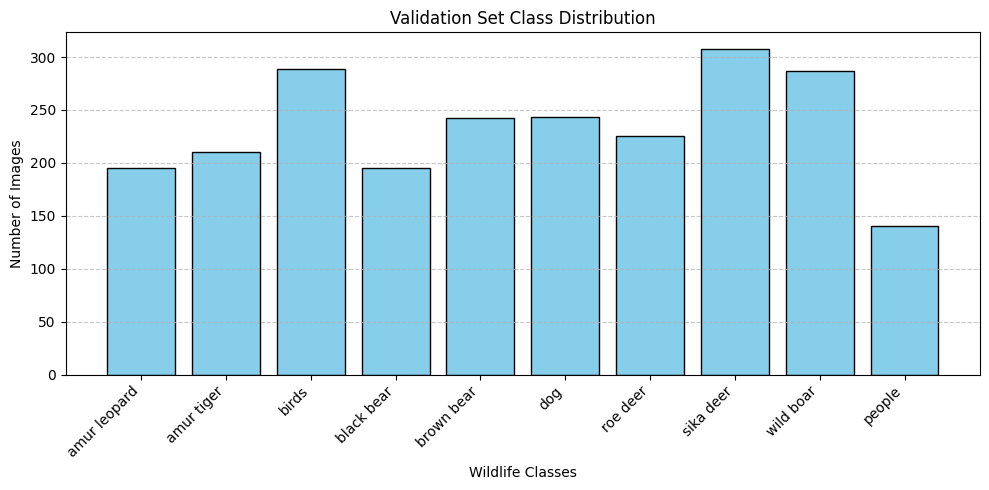

In [ ]:

CLASS_MAPPING = {'amur leopard': 0, 'amur tiger': 1, 'birds': 2, 'black bear': 3,
    'brown bear': 4, 'dog': 5, 'roe deer': 6, 'sika deer': 7,
    'wild boar': 8, 'people': 9}

dataset_root = "/content/dataset" 
all_image_paths = []
all_labels = []

for root, dirs, files in os.walk(dataset_root):
    
    folder_name = os.path.basename(root).lower().replace('_', ' ')

    if folder_name in CLASS_MAPPING:
        label_idx = CLASS_MAPPING[folder_name]
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(root, file))
                all_labels.append(label_idx)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=2023471
)

class RussianWildlifeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

wandb.login() 
wandb.init(project="russian-wildlife-classification", name="cnn-from-scratch")


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RussianWildlifeDataset(train_paths, train_labels, transform=transform)
val_dataset = RussianWildlifeDataset(val_paths, val_labels, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



def plot_distribution(labels, title):
    counts = Counter(labels)
    idx_to_class = {v: k for k, v in CLASS_MAPPING.items()}

    sorted_classes = sorted(counts.keys())
    names = [idx_to_class[i] for i in sorted_classes]
    frequencies = [counts[i] for i in sorted_classes]

    plt.figure(figsize=(10, 5))
    plt.bar(names, frequencies, color='skyblue', edgecolor='black')
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.xlabel('Wildlife Classes')
    plt.ylabel('Number of Images')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

print(f"Total Training Images: {len(train_labels)}")
print(f"Total Validation Images: {len(val_labels)}")

plot_distribution(train_labels, "Training Set Class Distribution")
plot_distribution(val_labels, "Validation Set Class Distribution")

In [ ]:
import torch.nn as nn
import torch.optim as optim


class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=4, stride=4)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu = nn.ReLU()

        self.fc = nn.Linear(128 * 14 * 14, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} 🚀")
model = CustomCNN(num_classes=10).to(device)



criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

print("Starting training...")
for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

   
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_accuracy": val_accuracy
    })

print("Training complete! Check your WandB dashboard for the plots.")

Using device: cpu 🚀
Starting training...


KeyboardInterrupt: 

Evaluating model on validation set...

✅ Validation Accuracy: 63.92%
✅ Validation F1-Score: 0.6406


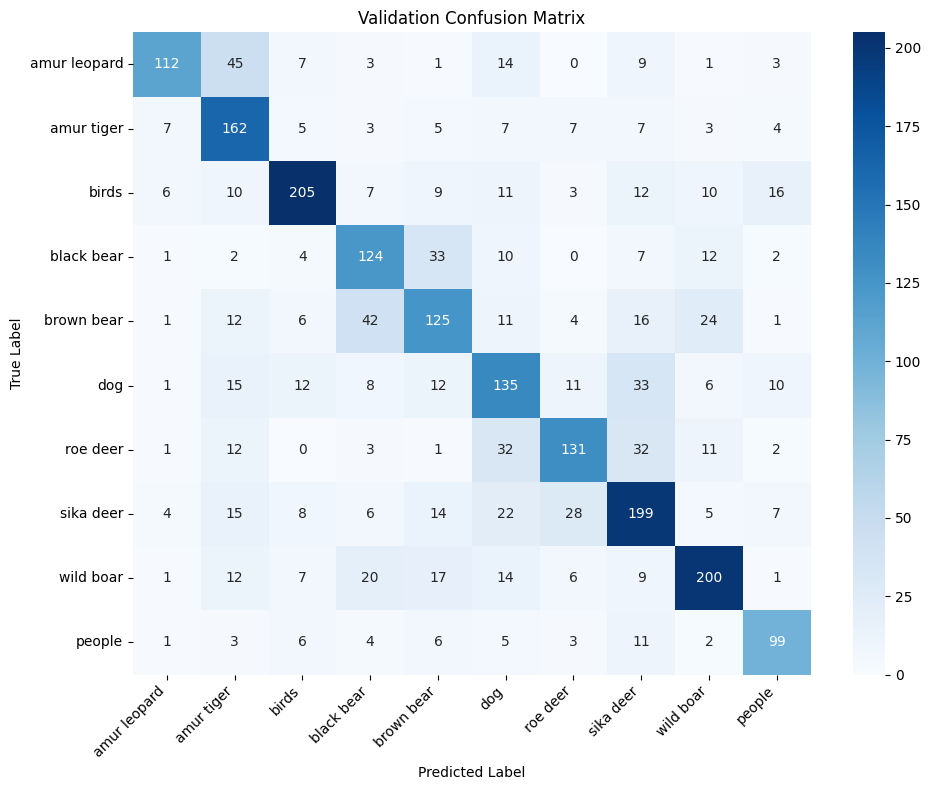


Generating misclassified images...


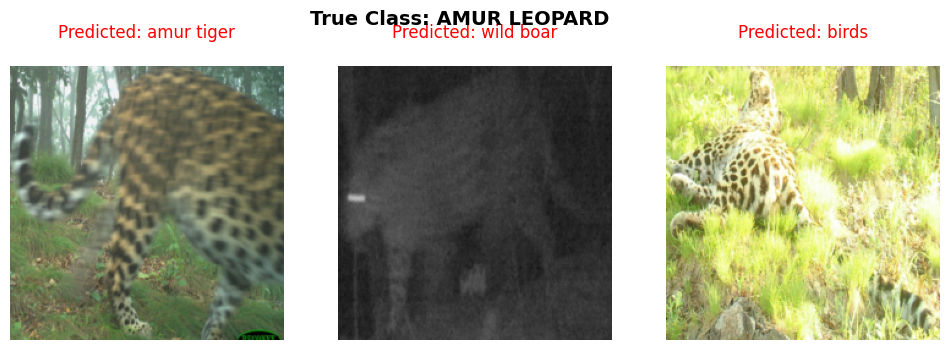

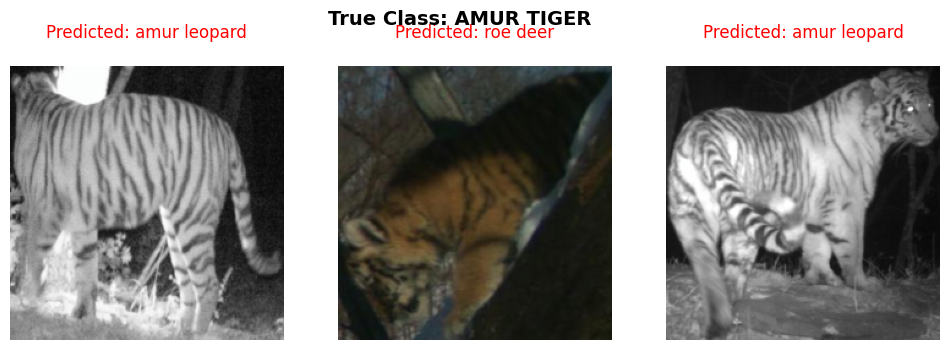

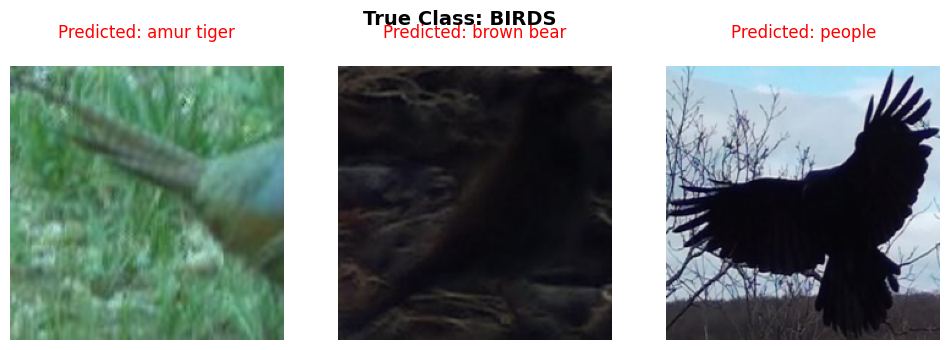

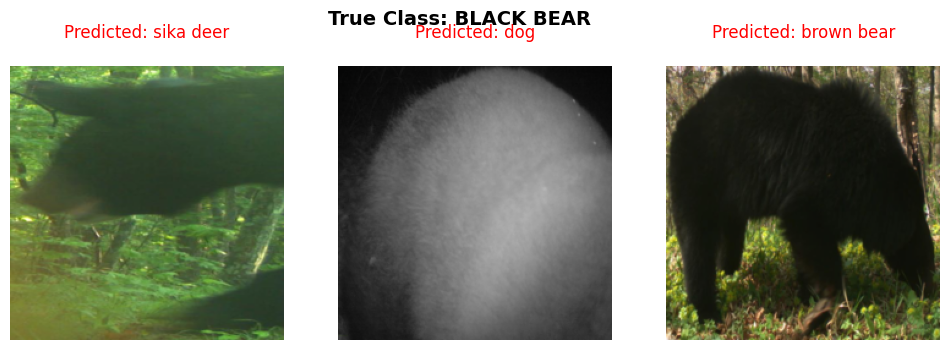

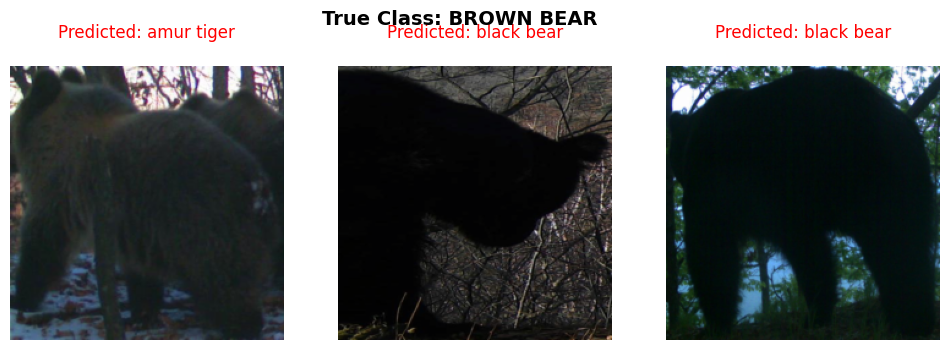

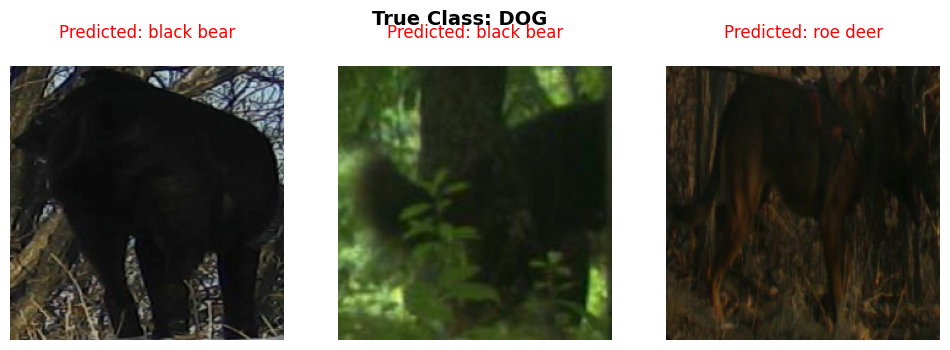

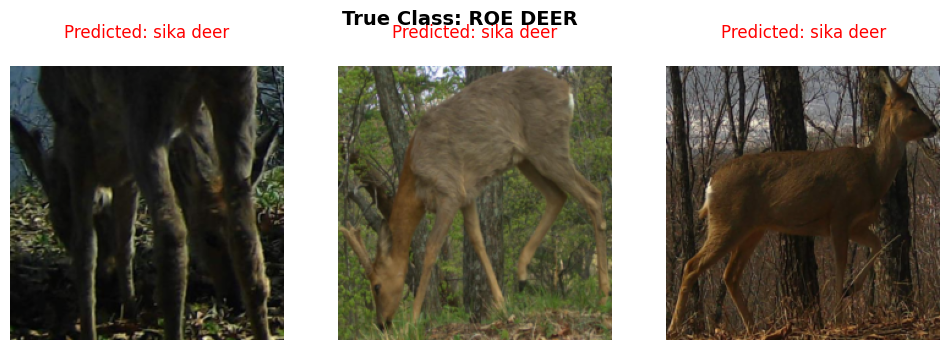

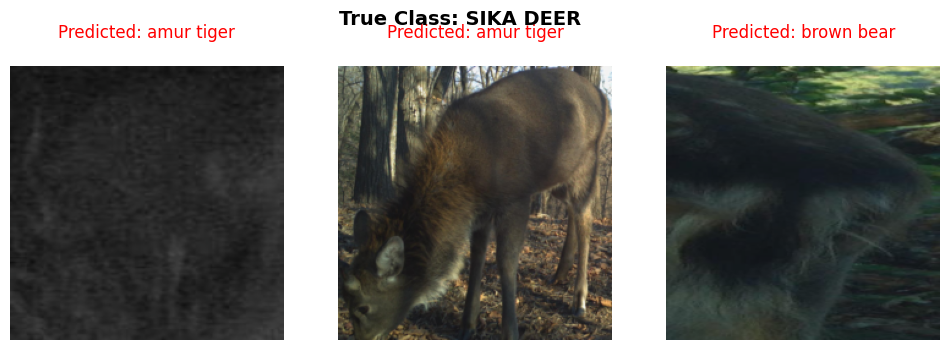

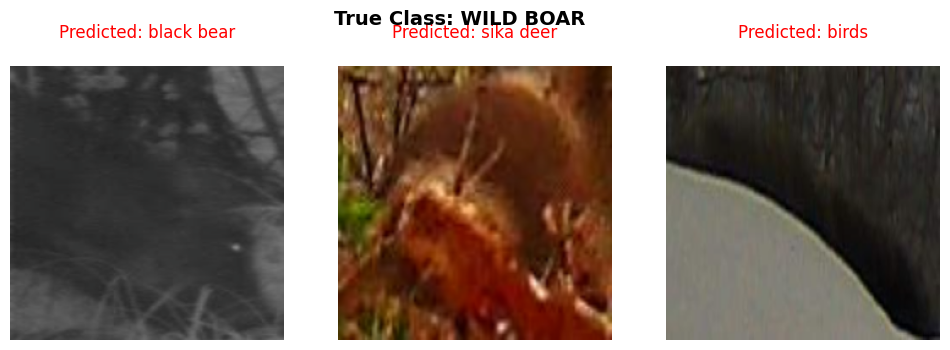

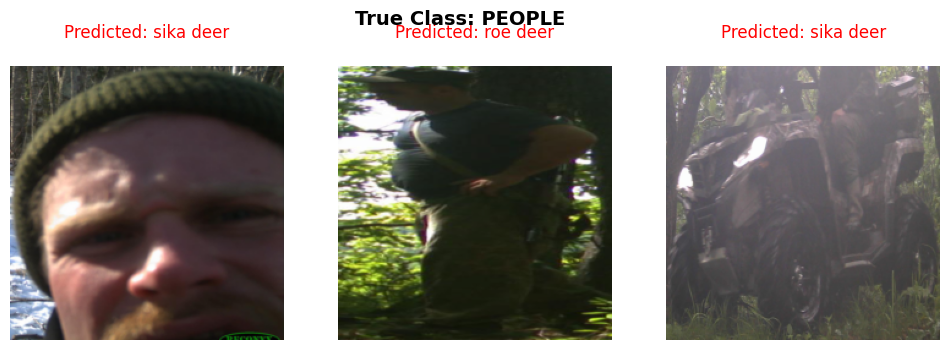

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


model.eval()
all_preds = []
all_trues = []
misclassified_data = {i: [] for i in range(10)}

print("Evaluating model on validation set...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(labels.cpu().numpy())

        for i in range(len(labels)):
            true_label = labels[i].item()
            pred_label = preds[i].item()
            if true_label != pred_label:

                misclassified_data[true_label].append({
                    'image': images[i].cpu(),
                    'pred': pred_label
                })

val_acc = accuracy_score(all_trues, all_preds)
val_f1 = f1_score(all_trues, all_preds, average='weighted')

print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")
print(f"✅ Validation F1-Score: {val_f1:.4f}")


class_names = [k for k in CLASS_MAPPING.keys()]
wandb.log({"conf_mat": wandb.plot.confusion_matrix(
    probs=None,
    y_true=all_trues,
    preds=all_preds,
    class_names=class_names
)})

cm = confusion_matrix(all_trues, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\nGenerating misclassified images...")

def imshow_unnormalized(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    return img

idx_to_class = {v: k for k, v in CLASS_MAPPING.items()}

for class_idx in range(10):
    mistakes = misclassified_data[class_idx]
    if len(mistakes) == 0:
        continue


    samples = mistakes[:3]

    fig, axes = plt.subplots(1, len(samples), figsize=(12, 4))
    if len(samples) == 1:
        axes = [axes]

    fig.suptitle(f"True Class: {idx_to_class[class_idx].upper()}", fontsize=14, fontweight='bold')

    for ax, sample in zip(axes, samples):
        img = imshow_unnormalized(sample['image'])
        ax.imshow(img)
        ax.set_title(f"Predicted: {idx_to_class[sample['pred']]}\n", color='red')
        ax.axis('off')
    plt.show()

epoch,▁▂▃▅▆▇█
train_loss,█▅▃▃▂▁▁
val_accuracy,▁▇▇███▇
val_loss,█▂▂▁▂▂▂
epoch,7
train_loss,0.2065
val_accuracy,77.54927
val_loss,0.74861


Starting ResNet-18 Training...
Epoch [1/10] | Train Loss: 1.0574 | Val Loss: 0.8292 | Val Acc: 70.14%
Epoch [2/10] | Train Loss: 0.6888 | Val Loss: 1.0425 | Val Acc: 66.71%
Epoch [3/10] | Train Loss: 0.5129 | Val Loss: 0.6325 | Val Acc: 78.75%
Epoch [4/10] | Train Loss: 0.4053 | Val Loss: 0.6154 | Val Acc: 80.21%
Epoch [5/10] | Train Loss: 0.3241 | Val Loss: 0.8828 | Val Acc: 76.09%
Epoch [6/10] | Train Loss: 0.2595 | Val Loss: 0.7097 | Val Acc: 78.58%
Epoch [7/10] | Train Loss: 0.1930 | Val Loss: 0.9355 | Val Acc: 75.71%
Epoch [8/10] | Train Loss: 0.1778 | Val Loss: 0.6275 | Val Acc: 82.26%
Epoch [9/10] | Train Loss: 0.1505 | Val Loss: 0.6134 | Val Acc: 83.16%
Epoch [10/10] | Train Loss: 0.1337 | Val Loss: 0.6927 | Val Acc: 81.32%

Evaluating ResNet-18 on validation set...

✅ ResNet-18 Validation Accuracy: 81.32%
✅ ResNet-18 Validation F1-Score: 0.8111


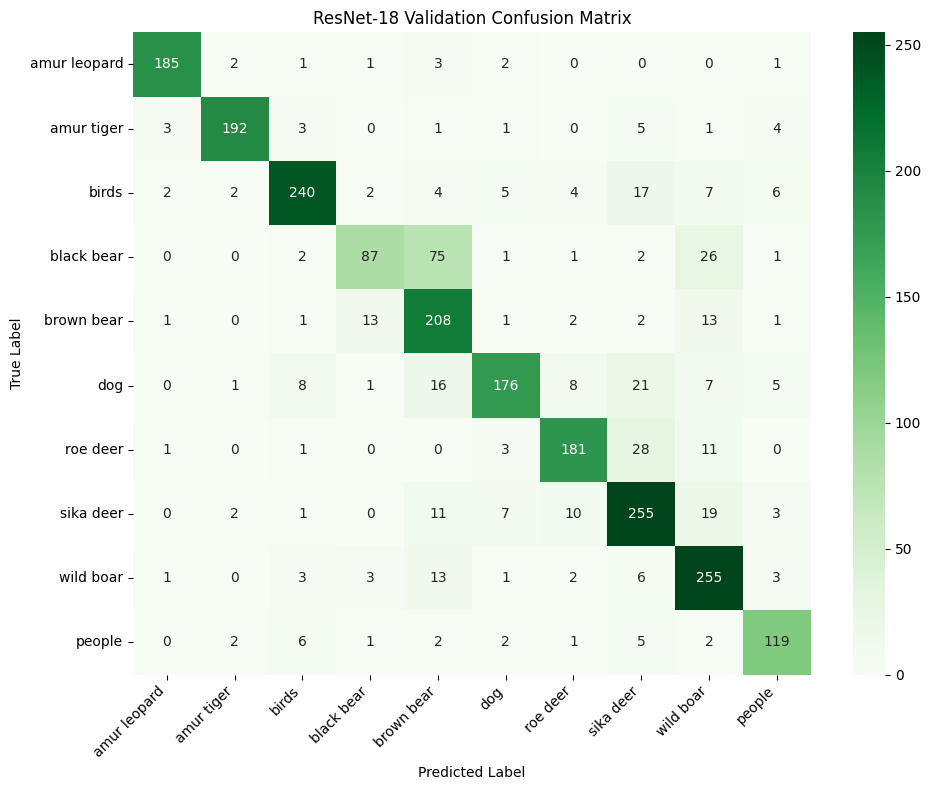

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▅▄▃▂▂▁▁▁▁
val_accuracy,▂▁▆▇▅▆▅██▇
val_loss,▅█▁▁▅▃▆▁▁▂
epoch,10
train_loss,0.13375
val_accuracy,81.31962
val_loss,0.69265


In [ ]:
import torchvision.models as models
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import numpy as np

wandb.init(project="russian-wildlife-classification", name="resnet18-finetuned")


resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)
num_epochs = 10

print("Starting ResNet-18 Training...")
for epoch in range(num_epochs):

    resnet_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    resnet_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_accuracy": val_accuracy
    })


print("\nEvaluating ResNet-18 on validation set...")
resnet_model.eval()
all_preds_res = []
all_trues_res = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds_res.extend(preds.cpu().numpy())
        all_trues_res.extend(labels.cpu().numpy())

val_acc_res = accuracy_score(all_trues_res, all_preds_res)
val_f1_res = f1_score(all_trues_res, all_preds_res, average='weighted')

print(f"\n✅ ResNet-18 Validation Accuracy: {val_acc_res*100:.2f}%")
print(f"✅ ResNet-18 Validation F1-Score: {val_f1_res:.4f}")

class_names = [k for k in CLASS_MAPPING.keys()]
wandb.log({"resnet_conf_mat": wandb.plot.confusion_matrix(
    probs=None,
    y_true=all_trues_res,
    preds=all_preds_res,
    class_names=class_names
)})


cm_res = confusion_matrix(all_trues_res, all_preds_res)
plt.figure(figsize=(10,8))
sns.heatmap(cm_res, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet-18 Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

wandb.finish()

Loading Dinov2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 241MB/s]


Extracting features from validation set. This might take a minute...
Running t-SNE reduction...


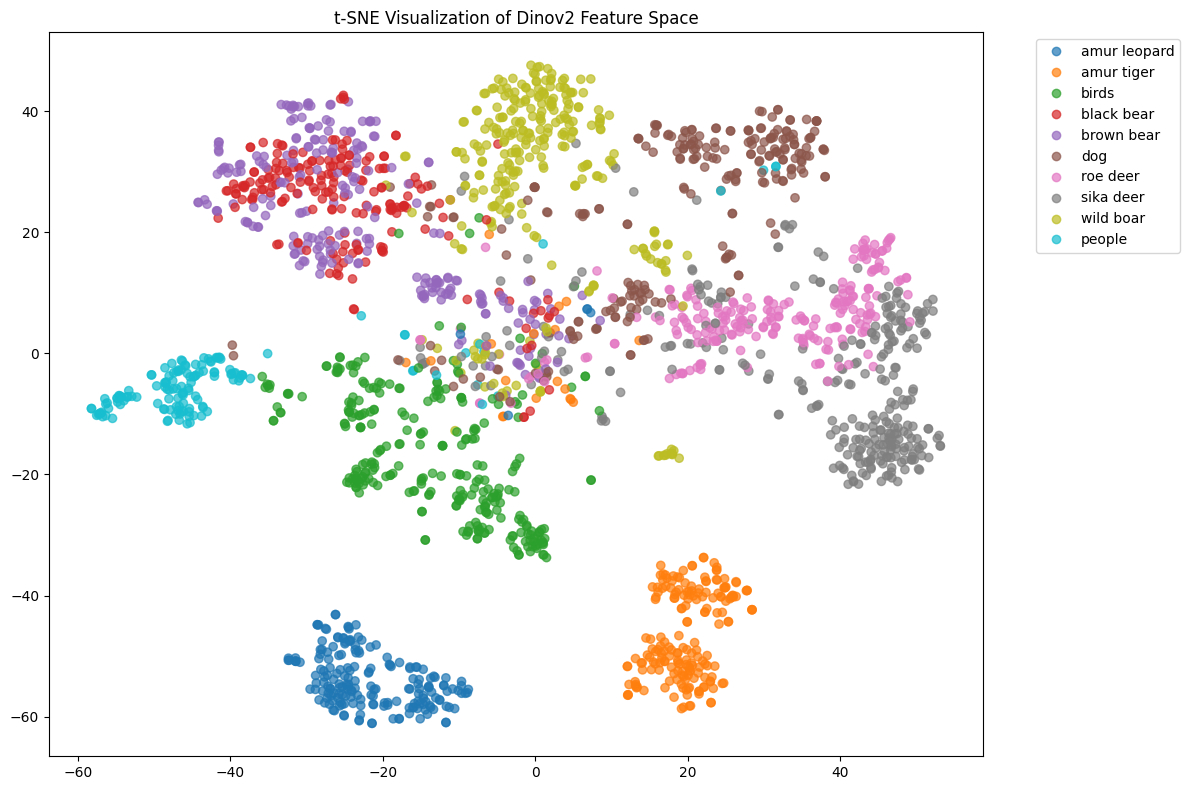

Clustering features using KMeans...
Plotting 16 images that Dinov2 grouped into Cluster 0...


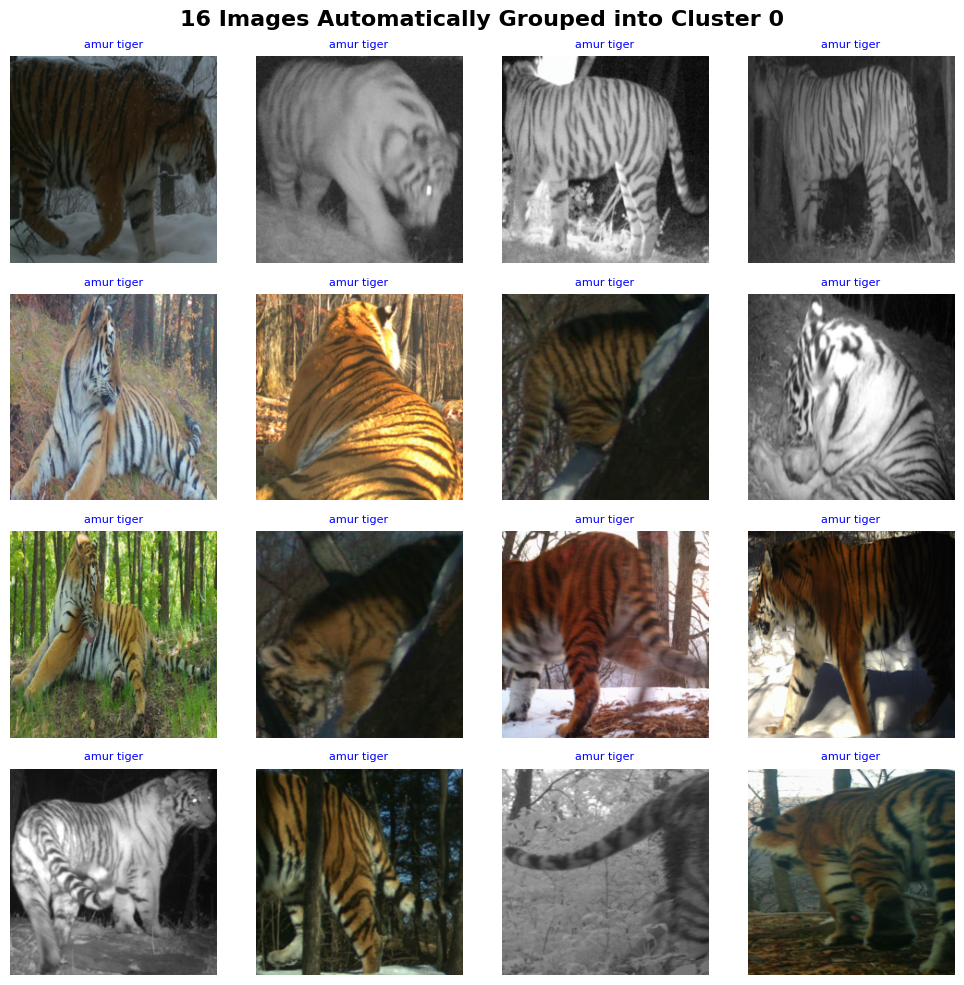

In [ ]:
import torch
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


def imshow_unnormalized(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

print("Loading Dinov2...")
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
dinov2.eval()

features_list = []
labels_list = []
original_images = []

print("Extracting features from validation set. This might take a minute...")
with torch.no_grad():
    for images, labels in val_loader:
        images_device = images.to(device)

        features = dinov2(images_device)
        features_list.extend(features.cpu().numpy())
        labels_list.extend(labels.numpy())

        if len(original_images) < 300:
            original_images.extend(images.cpu())

features_array = np.array(features_list)
labels_array = np.array(labels_list)
class_names = [k for k in CLASS_MAPPING.keys()]

print("Running t-SNE reduction...")
tsne = TSNE(n_components=2, random_state=2023471)
features_2d = tsne.fit_transform(features_array)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_array, cmap='tab10', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization of Dinov2 Feature Space")
plt.tight_layout()
plt.show()


print("Clustering features using KMeans...")
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(features_array)

target_cluster = 0
cluster_indices = np.where(clusters == target_cluster)[0]

print(f"Plotting 16 images that Dinov2 grouped into Cluster {target_cluster}...")
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f"16 Images Automatically Grouped into Cluster {target_cluster}", fontsize=16, fontweight='bold')

count = 0
for idx in cluster_indices:
    if count >= 16:
        break
    if idx < len(original_images):
        img = imshow_unnormalized(original_images[idx])
        ax = axes[count // 4, count % 4]
        ax.imshow(img)
        ax.axis('off')

        true_label = class_names[labels_array[idx]]
        ax.set_title(true_label, fontsize=8, color='blue')
        count += 1

plt.tight_layout()
plt.show()

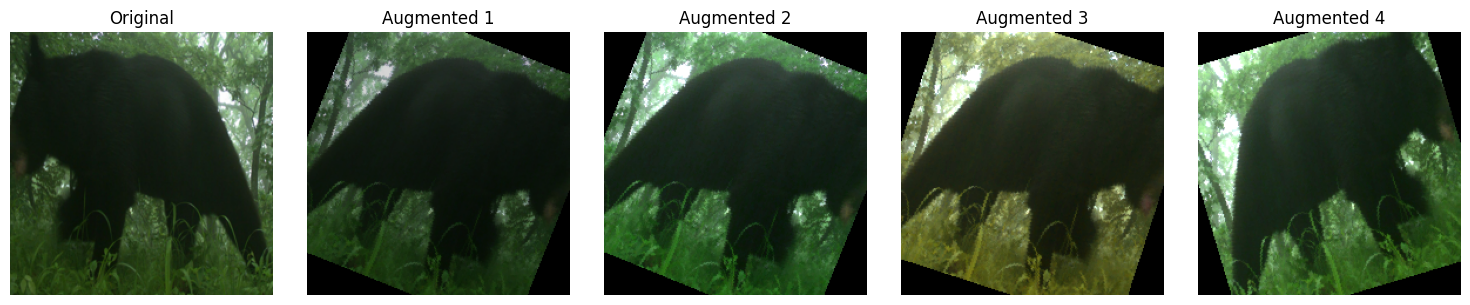

Creating augmented dataset and dataloader...


Using device: cuda 🚀
Starting training with Data Augmentation...
Epoch [1/10] | Train Loss: 1.9553 | Val Loss: 1.7408 | Val Acc: 39.97%
Epoch [2/10] | Train Loss: 1.6369 | Val Loss: 1.4930 | Val Acc: 48.80%
Epoch [3/10] | Train Loss: 1.4695 | Val Loss: 1.3659 | Val Acc: 54.58%
Epoch [4/10] | Train Loss: 1.3714 | Val Loss: 1.2666 | Val Acc: 58.48%
Epoch [5/10] | Train Loss: 1.2834 | Val Loss: 1.2779 | Val Acc: 57.41%
Epoch [6/10] | Train Loss: 1.2271 | Val Loss: 1.2182 | Val Acc: 59.85%
Epoch [7/10] | Train Loss: 1.1728 | Val Loss: 1.1689 | Val Acc: 61.05%
Epoch [8/10] | Train Loss: 1.1231 | Val Loss: 1.1369 | Val Acc: 62.90%
Epoch [9/10] | Train Loss: 1.0693 | Val Loss: 1.1764 | Val Acc: 62.38%
Epoch [10/10] | Train Loss: 1.0505 | Val Loss: 1.0886 | Val Acc: 63.84%


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▆▄▃▃▂▂▂▁▁
val_accuracy,▁▄▅▆▆▇▇███
val_loss,█▅▄▃▃▂▂▂▂▁
epoch,10
train_loss,1.05052
val_accuracy,63.8389
val_loss,1.08859


In [ ]:
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import wandb
import torch

train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0),           
    transforms.ColorJitter(brightness=0.5, hue=0.1), 
    transforms.RandomRotation(degrees=30),          
    transforms.ToTensor(),
])

sample_image_path = train_paths[0]
original_pil_img = Image.open(sample_image_path).convert("RGB")


augmented_images = [train_transform_aug(original_pil_img) for _ in range(4)]


fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(original_pil_img.resize((224, 224)))
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(4):
    aug_img = augmented_images[i].numpy().transpose((1, 2, 0))
    axes[i+1].imshow(aug_img)
    axes[i+1].set_title(f"Augmented {i+1}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

final_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Creating augmented dataset and dataloader...")
train_dataset_aug = RussianWildlifeDataset(train_paths, train_labels, transform=final_train_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)


wandb.init(project="russian-wildlife-classification", name="resnet18-augmented")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} 🚀")

aug_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


num_ftrs = aug_model.fc.in_features
aug_model.fc = nn.Linear(num_ftrs, 10)
aug_model = aug_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(aug_model.parameters(), lr=1e-4)
num_epochs = 10

print("Starting ResNet18 training with Data Augmentation...")
for epoch in range(num_epochs):

    aug_model.train()
    running_loss = 0.0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = aug_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader_aug.dataset)


    aug_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = aug_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "val_accuracy": val_accuracy
    })

wandb.finish()
print("Augmented ResNet18 Training Complete!")

Evaluating Augmented CNN on validation set...

✅ Augmented CNN Validation Accuracy: 63.84%
✅ Augmented CNN Validation F1-Score: 0.6388


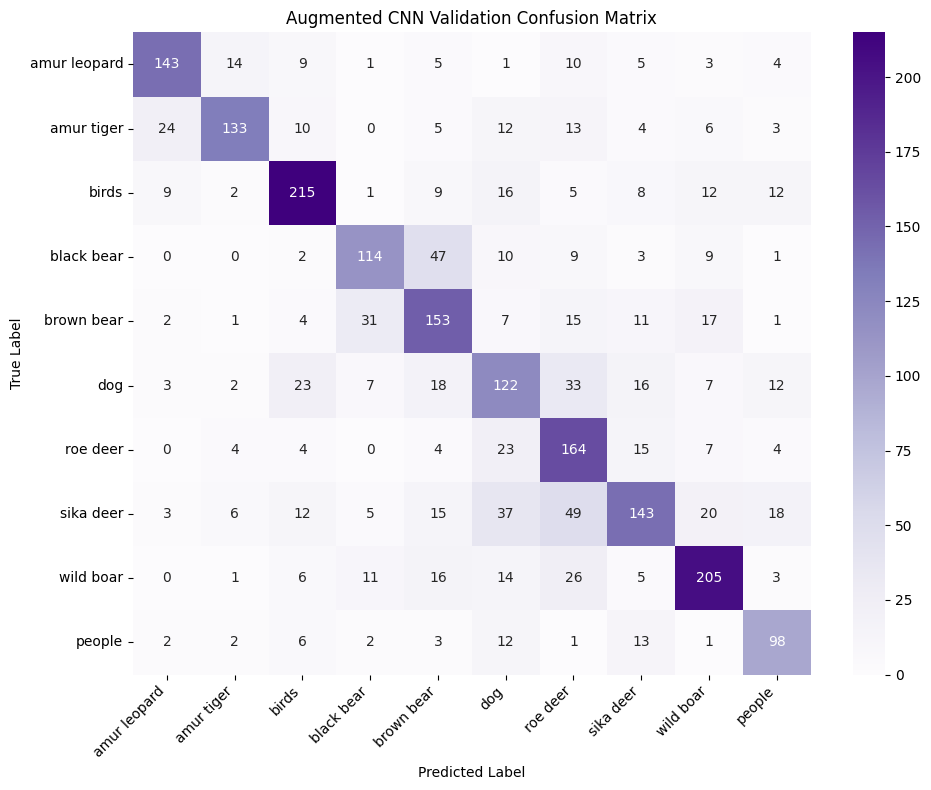

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import wandb

print("Evaluating Augmented on validation set...")
aug_model.eval()
all_preds_aug = []
all_trues_aug = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = aug_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds_aug.extend(preds.cpu().numpy())
        all_trues_aug.extend(labels.cpu().numpy())

val_acc_aug = accuracy_score(all_trues_aug, all_preds_aug)
val_f1_aug = f1_score(all_trues_aug, all_preds_aug, average='weighted')

print(f"\n✅ Augmented Validation Accuracy: {val_acc_aug*100:.2f}%")
print(f"✅ Augmented Validation F1-Score: {val_f1_aug:.4f}")

wandb.init(project="russian-wildlife-classification", name="cnn-augmented-eval")


class_names = [k for k in CLASS_MAPPING.keys()]
wandb.log({"aug_cnn_conf_mat": wandb.plot.confusion_matrix(
    probs=None,
    y_true=all_trues_aug,
    preds=all_preds_aug,
    class_names=class_names
)})


cm_aug = confusion_matrix(all_trues_aug, all_preds_aug)
plt.figure(figsize=(10,8))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Purples',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Augmented CNN Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

wandb.finish()